In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("assignment3.ipynb")

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Assignment-4:-Modeling-and-Optimization" data-toc-modified-id="Assignment-4:-Modeling-and-Optimization-1">Assignment 4: Modeling and Optimization</a></span></li><li><span><a href="#Questions-1-3:-Resource-Allocation-Problem" data-toc-modified-id="Questions-1-3:-Resource-Allocation-Problem-2">Questions 1-3: Resource Allocation Problem</a></span><ul class="toc-item"><li><span><a href="#Question-1:-Resource-Constraints" data-toc-modified-id="Question-1:-Resource-Constraints-2.1">Question 1: Resource Constraints</a></span><ul class="toc-item"><li><span><a href="#Question-1.a:-Modeling-Resource-Usage" data-toc-modified-id="Question-1.a:-Modeling-Resource-Usage-2.1.1">Question 1.a: Modeling Resource Usage</a></span></li><li><span><a href="#Question-1.b:--Resource-Usage-vs.-Total-Resource-Constraint" data-toc-modified-id="Question-1.b:--Resource-Usage-vs.-Total-Resource-Constraint-2.1.2">Question 1.b:  Resource Usage vs. Total Resource Constraint</a></span></li><li><span><a href="#Question-1.c:-Feasible-Region-Boundary" data-toc-modified-id="Question-1.c:-Feasible-Region-Boundary-2.1.3">Question 1.c: Feasible Region Boundary</a></span></li><li><span><a href="#Question-1.d:-Interior-of-Feasible-Region" data-toc-modified-id="Question-1.d:-Interior-of-Feasible-Region-2.1.4">Question 1.d: Interior of Feasible Region</a></span></li><li><span><a href="#Question-1.e:-Visualizing-the-Feasible-Region" data-toc-modified-id="Question-1.e:-Visualizing-the-Feasible-Region-2.1.5">Question 1.e: Visualizing the Feasible Region</a></span></li></ul></li><li><span><a href="#Question-2:-Objective-Function" data-toc-modified-id="Question-2:-Objective-Function-2.2">Question 2: Objective Function</a></span><ul class="toc-item"><li><span><a href="#Question-2.a:-Defining-Objective-Function" data-toc-modified-id="Question-2.a:-Defining-Objective-Function-2.2.1">Question 2.a: Defining Objective Function</a></span></li><li><span><a href="#Question-2.b:-Direction-of-Steepest-Increase" data-toc-modified-id="Question-2.b:-Direction-of-Steepest-Increase-2.2.2">Question 2.b: Direction of Steepest Increase</a></span></li></ul></li><li><span><a href="#Question-3:-Putting-Pieces-Together" data-toc-modified-id="Question-3:-Putting-Pieces-Together-2.3">Question 3: Putting Pieces Together</a></span><ul class="toc-item"><li><span><a href="#Question-3.a:-Standard-Form-of-a-Linear-Programming-Problem" data-toc-modified-id="Question-3.a:-Standard-Form-of-a-Linear-Programming-Problem-2.3.1">Question 3.a: Standard Form of a Linear Programming Problem</a></span></li><li><span><a href="#Question-3.b:-Computing-the-Numerical-Solution" data-toc-modified-id="Question-3.b:-Computing-the-Numerical-Solution-2.3.2">Question 3.b: Computing the Numerical Solution</a></span></li><li><span><a href="#Question-3.c:-Plotting-the-optimal-solution" data-toc-modified-id="Question-3.c:-Plotting-the-optimal-solution-2.3.3">Question 3.c: Plotting the optimal solution</a></span></li></ul></li></ul></li><li><span><a href="#Question-4:-Nutrition-Problem" data-toc-modified-id="Question-4:-Nutrition-Problem-3">Question 4: Nutrition Problem</a></span><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Question-4.a:-Define-Constraints" data-toc-modified-id="Question-4.a:-Define-Constraints-3.0.1">Question 4.a: Define Constraints</a></span></li><li><span><a href="#Question-4.b:-Create-Python-Variables" data-toc-modified-id="Question-4.b:-Create-Python-Variables-3.0.2">Question 4.b: Create Python Variables</a></span></li><li><span><a href="#Question-4.c:-Solve-the-Problem" data-toc-modified-id="Question-4.c:-Solve-the-Problem-3.0.3">Question 4.c: Solve the Problem</a></span></li><li><span><a href="#Question-4.d:-Interpreting-the-Results" data-toc-modified-id="Question-4.d:-Interpreting-the-Results-3.0.4">Question 4.d: Interpreting the Results</a></span></li></ul></li></ul></li></ul></div>

# Assignment 3: Modeling and Optimization

Mathematical modeling of a problem at hand give us a systematic way of finding a solution. For example, a maximum likelihood estimator (assuming it exists), $\hat\theta$, is a method for finding the parameter that maximizes the likelihood of the data $L_n$:
$$L_{n}(\hat{\theta} ; x_1, x_2, \dots, x_n)=\max _{\theta \in \Theta} L_{n}(\theta ; x_1, x_2, \dots, x_n)$$
Data $x_1, x_2, \dots$, set of feasible parameters $\Theta$, and likelihood function $L_n$ are given. We find the parameter that "best" describe the data in the context of the likelihood function.

Many other applications of optimization exists, and this assignment will give a hands-on introduction to a simple linear programming problem.

In [2]:
import cvxpy as cp
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

# Questions 1-3: Resource Allocation Problem

Hint: refer to Chapter 2.B of [Introduction to Linear and Matrix Algebra](https://search.library.ucsb.edu/permalink/01UCSB_INST/1876c7q/cdi_springer_books_10_1007_978_3_030_52811_9) for examples.

You are in charge of a company that makes two hot sauces: $x_1$ liters of Kapatio and $x_2$ liters of Zriracha. We will use optimization technique to find the "best" manufacturing strategy given our resource constraints.

First, we need to define what we mean by "best" strategy. In this scenario, the goal is to obtain the highest revenue possible. While doing so, there are resource constraints we must satisfy. 


For example, in order to manufacture these two hot sauce products, different amount of peppers and vineger are needed. Also, we have only so much total resource available.

Ingridients | Kapatio | Zriracha | Total Available
----------- | ------- | -------- | ------------------
Pepper      | 5       | 7        | 30
Vineger     | 4       | 2        | 12

## Question 1: Resource Constraints



<!-- BEGIN QUESTION -->

### Question 1.a: Modeling Resource Usage

What is the equation for the amount of pepper needed to manufacture $x_1$ and $x_2$. What is the equation for the amount of vinegar?
(Use [Mathpix](https://mathpix.com/) to write equations)



**SOLUTION**

The equations for each ingredient are as follows

$$
\left\{
\begin{matrix}
y_{p} = 5x_1 + 7x_2 \\ 
y_{v} = 4x_1 + 2x_2
\end{matrix}
\right.
$$

For vinegar, the total amount used in manufacturing Kapatio and Zriracha is

$$
y_{v} = 4x_1 + 2x_2
$$

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Question 1.b1:  Resource Usage vs. Total Resource Constraint

Total amount of pepper needed cannot exceed total available. Write down the inequality expressing this relationship. Do the same for vinegar. These inequalities are your resource constraints.
Additinally, variables $x_1$ and $x_2$ are non-negative: i.e. amount of manufactured goods cannot be negative.

Rewrite the system of constraint inequalities into a matrix inequality: $Ax\leq b$, where $x=(x_1, x_2)^T$. Arrange rows of $A$ and $b$ such that:

* Row 1: total pepper amount constraint
* Row 2: total vinegar amount constraint
* Row 3: Kapatio non-negativity constraint
* Row 4: Zriracha non-negativity constraint

Less than symbol in $Ax\leq b$ means element-wise.



**SOLUTION**

Given total amount of pepper needed cannot exceed total available. We can generate inequality relationship based on the system of equations before.

$$
\left\{
\begin{matrix}
5x_1 + 7x_2 \leq 30 \\ 
4x_1 + 2x_2 \leq 12
\end{matrix}
\right.
$$

The non-negativity constraint ensures that the amount of Kapatio and Zriracha produced is non-negative, such that

$$
\left\{
\begin{matrix}
-x_1 \leq 0 \\ 
-x_2 \leq 0
\end{matrix}
\right.
$$

In matrix form

$$
\left[\begin{matrix}5 & 7 \\ 4 & 2 \end{matrix}\right]
\left[\begin{matrix}x_1 \\ x_2 \end{matrix}\right] \leq
\left[\begin{matrix}30 \\ 12 \end{matrix}\right]
$$

and

$$
\left[\begin{matrix}-1 & 0 \\ 0 & -1 \end{matrix}\right]
\left[\begin{matrix}x_1 \\ x_2 \end{matrix}\right] \leq
\left[\begin{matrix}0 \\ 0 \end{matrix}\right]
$$

Hence let $x=(x_1, x_2)^T$, then the above equation can be defined as

$$
\left[\begin{matrix}5 & 7 \\ 4 & 2 \\ -1 & 0  \\ 0 & -1\end{matrix}\right]
\left[\begin{matrix}x_1 \\ x_2 \end{matrix}\right] \leq
\left[\begin{matrix} 30 \\ 12 \\ 0 \\ 0\end{matrix}\right]
$$

<!-- END QUESTION -->

### Question 1.b2: Define Matrix Inequality in Code

Define matrix `A1` and vector `b1` in code according to matrix inequality above.


In [3]:
A1 = np.matrix([[5, 7], 
               [4, 2], 
               [-1, 0], 
               [0, -1]])

b1 = np.array([30, 12, 0, 0])

In [4]:
grader.check("q1b2")

q1b2 results: All test cases passed!

### Visualizing Feasible Region <a class="tocSkip">
In a 2-dimensional plot, we will visualize the area that satisfies both of the resource constraints. Draw $x_1$ on the horizontal axis and $x_2$ on the vertical axis. 

There will be two main components to the plot:
* **Lines** indicating constraint boundaries:  
    e.g. the constraint $x_2\geq 0$ has boundary at $x_2 = 0$.
* **Shaded area** indicating feasible regions:  
    e.g., the whole region $x_2 > 0$ is to be shaded _if_ $x_2\geq 0$ was the only constraint. We will use shading to indicate the region where _all_ constraints are satisfied.

In [5]:
x1_line = np.linspace(-1, 10, 500)
x2_line = np.linspace(-1, 10, 500)

<!-- BEGIN QUESTION -->

### Question 1.c: Feasible Region Boundary

In a list named `boundary`, create four data frames for each equality in $Ax=b$. These lines indicate where the feasible area ends. Set column names as

* `$x_1$`
* `$x_2$`
* `constraints`

Note the use of latex codes (feel free to use [Mathpix](https://mathpix.com/)). 

#### Toy Example: Drawing Boundaries <a class="tocSkip">

Here is a **toy example** of drawing two constraint boundaries by constructing data frames:

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

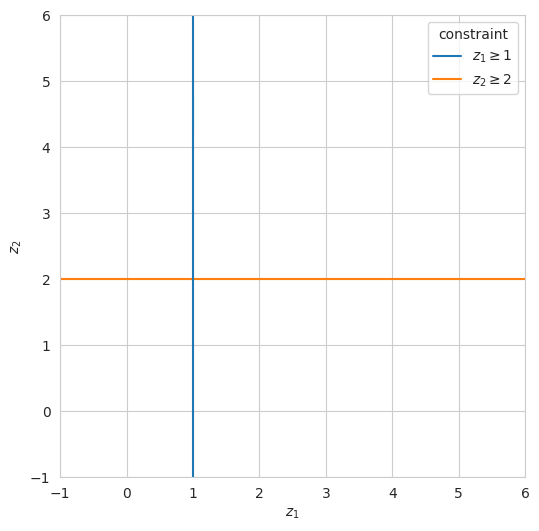

In [6]:
z1_line = np.linspace(-1, 10, 500)
z2_line = np.linspace(-1, 10, 500)

boundary = [
    pd.DataFrame({
        '$z_1$': np.ones_like(z2_line)*1,
        '$z_2$': z2_line,
        'constraint': '$z_1\geq 1$'
    }),
    pd.DataFrame({
        '$z_1$': z1_line,
        '$z_2$': np.ones_like(z1_line)*2,
        'constraint': '$z_2\geq 2$'
    }),
]
fig, ax = plt.subplots(figsize=(6, 6))
sns.lineplot(x='$z_1$', y='$z_2$', hue='constraint', data=pd.concat(boundary).reset_index(), ax=ax).axvline(1)
plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.show()

Sometimes, things just do not work as expected. 

In the toy example code, 
```
sns.lineplot(x='$z_1$', y='$z_2$', hue='constraint', data=pd.concat(boundary), ax=ax).axvline(1)
```
what seems strange about the plotting command? Why was the strange code necessary?


**SOLUTION**

<!-- END QUESTION -->

#### Example: Resource Constraint Boundary  <a class="tocSkip">

Now, create a data frame for the non-negativity constraint $x_2\geq 0$ as follows:

In [7]:
pd.DataFrame({'$x_1$':x1_line,               ## x_1 can take on any value
              '$x_2$':x1_line * 0.0,         ## x_2 = 0
              'constraint':'$x_2 \geq 0$'}), ## constraint equation for labeling

(         $x_1$  $x_2$    constraint
 0    -1.000000   -0.0  $x_2 \geq 0$
 1    -0.977956   -0.0  $x_2 \geq 0$
 2    -0.955912   -0.0  $x_2 \geq 0$
 3    -0.933868   -0.0  $x_2 \geq 0$
 4    -0.911824   -0.0  $x_2 \geq 0$
 ..         ...    ...           ...
 495   9.911824    0.0  $x_2 \geq 0$
 496   9.933868    0.0  $x_2 \geq 0$
 497   9.955912    0.0  $x_2 \geq 0$
 498   9.977956    0.0  $x_2 \geq 0$
 499  10.000000    0.0  $x_2 \geq 0$
 
 [500 rows x 3 columns],)

Create a list named `boundary` containing four data frames (each corresponding to a constraint). Concatenate data frames in `boundary` to one data frame named `hull`.



In [8]:
boundary = [
    pd.DataFrame({'$x_1$': x1_line,
                  '$x_2$': (30 - 5 * x1_line) / 7,
                  'constraint':'$5x_1 + 7x_2 \leq 30$'}),
    pd.DataFrame({'$x_1$': x1_line,
                  '$x_2$': (12 - 4 * x1_line) / 2,
                  'constraint':'$4x_1 + 2x_2 \leq 12$'}),
    pd.DataFrame({'$x_1$': x2_line * 0.0, 
                  '$x_2$': x2_line,
                  'constraint':'$x_1 \geq 0$'}),
    pd.DataFrame({'$x_1$':x1_line,               ## x_1 can take on any value
              '$x_2$':x1_line * 0.0,         ## x_2 = 0
              'constraint':'$x_2 \geq 0$'})]

hull = pd.concat(boundary, ignore_index=True)

In [9]:
grader.check("q1c2")

q1c2 results: All test cases passed!

### Question 1.d: Interior of Feasible Region

Previous question prepared constraint boundaries, $Ax = b$. In this question, we calculate the interior of the feasible region, which will be shaded in the visualization. First, create a 2-d array of $x_1$ and $x_2$ values. If a point $(x_1, x_2)$ satisfies _every_ constraint, the point will be colored grey.

For example, in order to shade $\{x_1: x_1\geq 1\}\cap\{x_2: x_2\geq 2\}$, we can use the `imshow` method. 

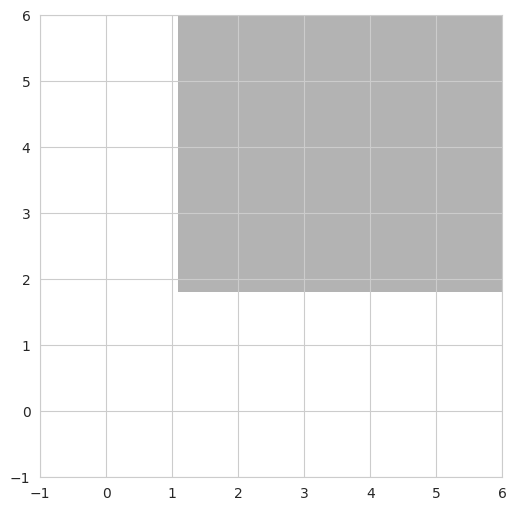

In [10]:
z1_line = np.linspace(-1, 6, 10)
z2_line = np.linspace(-1, 6, 10)
z1_grid, z2_grid = np.meshgrid(z1_line, z2_line)

fig, az = plt.subplots(figsize=(6, 6))
az.imshow(
    ((z1_grid >= 1) & (z2_grid >= 2)).astype(int),
    origin='lower',
    extent=(z1_grid.min(), z1_grid.max(), z2_grid.min(), z2_grid.max()),
    cmap="Greys", alpha=0.3, aspect='equal' 
)
plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.show()

<!-- BEGIN QUESTION -->

By dissecting the command below and reading the documentation, report what each of the following lines does:

* `((y1_grid >= 1) & (y2_grid >= 2)).astype(int)` (What is the output of running this command?)  
* `origin='lower'`  
* `extent=(y1_grid.min(), y1_grid.max(), y2_grid.min(), y2_grid.max())`  
* `cmap='Greys'`  
* `alpha=0.3`  
* `aspect='equal'`  


**SOLUTION**

`((y1_grid >= 1) & (y2_grid >= 2)).astype(int)`: the output will have the same shape as `1_grid`and `y2_grid`, with values 1 where both conditions (y1_grid >= 1 and y2_grid >= 2) are meet and 0 elsewhere.

`origin='lower'`: set the origin (0,0) point at the bottom-left corner of the plot.

`extent=(y1_grid.min(), y1_grid.max(), y2_grid.min(), y2_grid.max())`: sets the minimum and maximum values of y1_grid for the horizontal extent and y2_grid for the vertical extent.

`cmap='Greys'`: sets the colormap for the plot using `grayscale colormap`

`alpha=0.3`: sets the transparency level of the plot to be 70% transparent. 

`aspect='equal'`: sets that one unit on the x-axis is the same length as one unit on the y-axis.


<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### Question 1.e: Visualizing the Feasible Region

Finally, create a figure that shows constraint boundaries and the interior region shaded with a light grey color.

Your output will look like this:  
![hull](images/feasible.png)


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

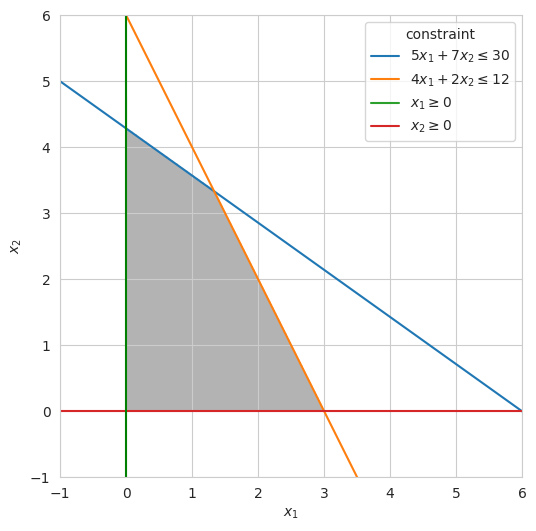

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
x1_grid, x2_grid = np.meshgrid(x1_line, x2_line)

ax.imshow(
    ((x1_grid >= 0) & (x2_grid >= 0) & (5 * x1_grid + 7 * x2_grid <= 30) & (4 * x1_grid + 2 * x2_grid <= 12)).astype(int),
    origin='lower',
    extent=(x1_grid.min(), x1_grid.max(), x2_grid.min(), x2_grid.max()),
    cmap="Greys", alpha = 0.3, aspect='equal')


# ax = sns.lineplot(???).axvline(???)
ax = sns.lineplot(
    data=hull, 
    x='$x_1$', 
    y='$x_2$', 
    hue='constraint'  # Using the 'constraint' column to label different lines
).axvline(0, color='green')
    
#ax.axvline(x=0, color='green')

plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.show()

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

In the context of linear programming, $Ax\leq b$ is called the _feasible region_ (including the appropriate sections of the boundaries). Denote the (shaded) feasible region as set $C$. Points $(x_1,x_2)\in C$ satisfy all of the constraints.

Describe in plain words the feasible region in the context of hot sauce manufacturing. Specifically, which constraint is violated (if any) by a point at:

* $(x_1,x_2) = (4, 1)$
* $(x_1,x_2) = (0, 5)$  
* $(x_1,x_2) = (3, 4)$  


**SOLUTION**

$(4,1)$ violates $4 x_1 + 2 x_2 \leq 12$

$(0,5)$ violates $4 x_1 + 2 x_2 \leq 12$ and $5 x_1 + 7 x_2 \leq 30$

$(3,4)$ violates $4 x_1 + 2 x_2 \leq 12$ and $5 x_1 + 7 x_2 \leq 30$

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Question 2: Objective Function

### Question 2.a: Defining Objective Function

Suppose the hot sauces are sold at the same price: \\$5 per liter. 

What is the equation $f(x)$ for the total revenue as a function of $x_1$ and $x_2$? 

The function $f(x)$ is called the objective function.


**SOLUTION**

$$
f(x)=5x_1+5x_2
$$

<!-- END QUESTION -->

Objective function $f(x)$ is a linear function in $x$. Therefore, $f(x)$ is a 2-dimesional hyperplane. Note that each value of $f(x)$ defines a line in $(x_1, x_2)$ plane.

For example, $f(x)= 0 = c_1x_1 + c_2x_2$ defines a line. A subspace of equal function value is sometimes referred to as a _level set_ or a _contour line_ when visualized.

First, create a numpy array of prices `c` for the two hot sauces, $x_1$ and $x_2$. Then, create a list `f_vals` containing four data frames of contour lines, $f(x) \in \{0, 10, 20, 30\}$. by creating one data frame for each contour line. 


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.u

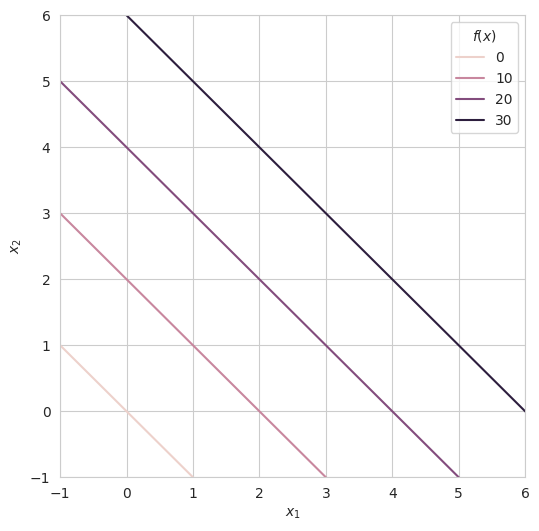

In [12]:
c = np.array([5,5])

fig, ax = plt.subplots(figsize=(6, 6))
contours = [
    pd.DataFrame({
        '$x_1$': x1_line,
        '$x_2$': ( 0 - c[0]*x1_line)/c[1],
        '$f(x)$': 0
    }),
    pd.DataFrame({
        '$x_1$': x1_line,
        '$x_2$': ( 10 - c[0]*x1_line)/c[1],
        '$f(x)$': 10
    }),
    pd.DataFrame({
        '$x_1$': x1_line,
        '$x_2$': ( 20 - c[0]*x1_line)/c[1],
        '$f(x)$': 20
    }),
    pd.DataFrame({
        '$x_1$': x1_line,
        '$x_2$': ( 30 - c[0]*x1_line)/c[1],
        '$f(x)$': 30
    })
]
f_vals = pd.concat(contours)

# ax = sns.lineplot(???)
ax = sns.lineplot(
    data=f_vals, 
    x='$x_1$', 
    y='$x_2$', 
    hue='$f(x)$',    
    ax=ax  
)

plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.show()

In [13]:
grader.check("q2a2")

q2a2 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Question 2.b: Direction of Steepest Increase

Since we want to maximize revenue, we want to increase our objective function as much as possible. Analogous to the minimization example given in a previous lecture, we can repeatedly move in the direction of function increase. In order to determine such direction, compute the gradient of $f(x)$ at $x=(0,0)^T$:
$$\nabla_x f(x) = \begin{pmatrix}\frac{\partial f(x)}{\partial x_1}\\\frac{\partial f(x)}{\partial x_2}\end{pmatrix} $$



**SOLUTION**

$$
\nabla_x f(x) = 
\begin{pmatrix}
\frac{\partial f(x)}{\partial x_1} \\
\frac{\partial f(x)}{\partial x_2}
\end{pmatrix} = 
\begin{pmatrix}
\frac{\partial }{\partial x_1}5x_1+5x_2 \\
\frac{\partial }{\partial x_2}5x_1+5x_2
\end{pmatrix} = 
\begin{pmatrix}
5 \\
5
\end{pmatrix}$$

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

## Question 3: Putting Pieces Together

### Question 3.a: Standard Form of a Linear Programming Problem

Write down the so-called the _standard form_ of a linear programming problem:
$$\begin{aligned}
\max_x & f(x)\\
\text{subject to } & Ax\leq b
\end{aligned}$$

Specifically, write the obejective as an inner product of two vectors: $f(x) = c^T x$, and write the constraint as a vector inequality involving a matrix-vector prduct: $Ax\leq b$, where $A$ is a 4-by-2 matrix.



**SOLUTION**

Write the obejective as an inner product of two vectors:

$$
f(x)=c^{T} x=\left[\begin{matrix}
5 &
5
\end{matrix}\right]
\left[\begin{matrix}x_1 \\ x_2 \end{matrix}\right]
$$

write the constraint as a vector inequality involving a matrix-vector prduct: $Ax\leq b$, where $A$ is a 4-by-2 matrix.

$$
\left[\begin{matrix}5 & 7 \\ 4 & 2 \\ -1 & 0  \\ 0 & -1\end{matrix}\right]
\left[\begin{matrix}x_1 \\ x_2 \end{matrix}\right] \leq
\left[\begin{matrix} 30 \\ 12 \\ 0 \\ 0\end{matrix}\right]
$$

<!-- END QUESTION -->

### Question 3.b: Computing the Numerical Solution

Therefore, _maximizing_ the revenue is a search over the feasible region for the best point $x^*=(x_1^*, x_2^*)$ that gives the largest revenue. On the otherhand, any _infeasible_ point _not_ in the feasible region cannot be a solution to the constrained optimization problem.

Notationally, the following expression means the same thing:
$$x^* = \arg\max_{\{x: Ax\leq b\}} f(x)$$

Using [CVXPY](https://www.cvxpy.org/), solve for the resource allocation problem with constraints.


In [14]:
# define variables
x = cp.Variable(2, nonneg=True)

# define the linear program
problem = cp.Problem(
    cp.Maximize(c @ x),
    [A1 @ x <= b1]
)

fstar1 = problem.solve()                                                 # maximum attained function value
xstar1 = pd.DataFrame(x.value.reshape(1, 2), columns=['$x_1$', '$x_2$']) # maximizer x for f

/usr/local/lib/python3.10/dist-packages/cvxpy/reductions/solvers/solving_chain.py:336: FutureWarning: 
    Your problem is being solved with the ECOS solver by default. Starting in 
    CVXPY 1.5.0, Clarabel will be used as the default solver instead. To continue 
    using ECOS, specify the ECOS solver explicitly using the ``solver=cp.ECOS`` 
    argument to the ``problem.solve`` method.
    
  warnings.warn(ECOS_DEPRECATION_MSG, FutureWarning)


In [15]:
grader.check("q3b")

q3b results: All test cases passed!

<!-- BEGIN QUESTION -->

### Question 3.c: Plotting the optimal solution


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dty

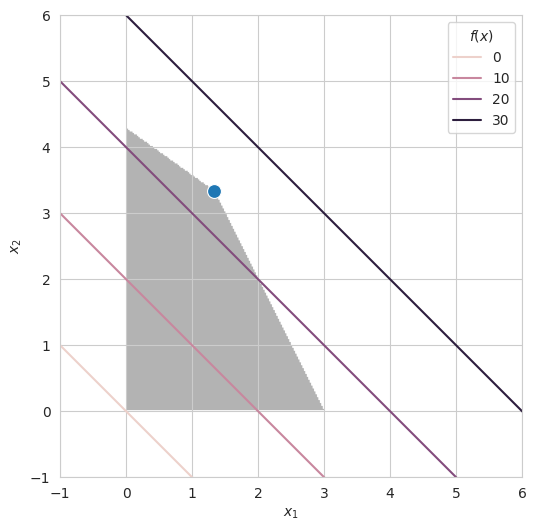

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
x1_grid, x2_grid = np.meshgrid(x1_line, x2_line)
ax.imshow(
    (
        (A1[0,0]*x1_grid + A1[0,1]*x2_grid <= b1[0]) & # Pepper constraints
        (A1[1,0]*x1_grid + A1[1,1]*x2_grid <= b1[1]) & # Vinegar constraints
        (A1[2,0]*x1_grid + A1[2,1]*x2_grid <= b1[2]) & 
        (A1[3,0]*x1_grid + A1[3,1]*x2_grid <= b1[3])   # non-negativity constraints 
    ),
    origin='lower',
    extent=(x1_grid.min(), x1_grid.max(), x2_grid.min(), x2_grid.max()),
    cmap="Greys", alpha = 0.3, aspect='equal' 
)
sns.scatterplot(x='$x_1$', y='$x_2$', data=xstar1, ax=ax, s=100)
sns.lineplot(x='$x_1$', y='$x_2$', hue='$f(x)$', data=f_vals.reset_index(), ax=ax)
plt.xlim(-1, 6)
plt.ylim(-1, 6)
plt.show()

<!-- END QUESTION -->

# Question 4: Nutrition Problem

During the second world war, the US Army set out to save money without damaging the nutritional health of members of the armed forces. 

> According to [this source](https://ibmdecisionoptimization.github.io/docplex-doc/mp/diet.html), the following problem is a _simple variation of the well-known diet problem that was posed by George Stigler and George Dantzig: how to choose foods that satisfy nutritional requirements while minimizing costs or maximizing satiety._
> 
> _Stigler solved his model "by hand" because technology at the time did not yet support more sophisticated methods. However, in 1947, Jack Laderman, of the US National Bureau of Standards, applied the simplex method (an algorithm that was recently proposed by George Dantzig) to Stigler’s model. Laderman and his team of nine linear programmers, working on desk calculators, showed that Stigler’s heuristic approximation was very close to optimal (only 24 cents per year over the optimum found by the simplex method) and thus demonstrated the practicality of the simplex method on large-scale, real-world problems._
> 
> _The problem that is solved in this example is to minimize the cost of a diet that satisfies certain nutritional constraints._

The file `foods.csv` in the `files` folder contains calorie, nutritional content, serving size, and price per serving information about 64 foods. Read it into a data frame named `foods`.

In [17]:
foods = pd.read_csv('files/foods.csv')
foods.head()

,Name,Calories,Cholesterol,Total_Fat,Sodium,Carbohydrates,Dietary_Fiber,Protein,Vit_A,Vit_C,Calcium,Iron,Serving,Price/Serving ($)
0,Frozen Broccoli,73.8,0.0,0.8,68.2,13.6,8.5,8.0,5867.4,160.2,159.0,2.3,10 Oz Pkg,0.16
1,"Carrots, Raw",23.7,0.0,0.1,19.2,5.6,1.6,0.6,15471.0,5.1,14.9,0.3,1/2 Cup Shredded,0.07
2,"Celery, Raw",6.4,0.0,0.1,34.8,1.5,0.7,0.3,53.6,2.8,16.0,0.2,1 Stalk,0.04
3,Frozen Corn,72.2,0.0,0.6,2.5,17.1,2.0,2.5,106.6,5.2,3.3,0.3,1/2 Cup,0.18
4,"Lettuce, Iceberg,Raw",2.6,0.0,0.0,1.8,0.4,0.3,0.2,66.0,0.8,3.8,0.1,1 Leaf,0.02


The file `nutritional_constraints.csv` in the `files` folder contains healthy nutritional range constraints. Minimum and maximum allowed nutritional contents can be found in this file. Name the variable `requirements`.

In [18]:
requirements = pd.read_csv('files/nutritional_constraints.csv')

requirements.head()

,Name,Unit,Min,Max
0,Calories,cal,2000,2250
1,Cholesterol,mg,0,300
2,Total_Fat,g,0,65
3,Sodium,mg,0,2400
4,Carbohydrates,g,0,300


Extract the nutritional content of foods into a 2-d array named `ncontent`. The dimension of `ncontent` DataFrame should be 11 rows and 64 columns.

In [19]:
ncontent = foods.iloc[:, 1:-2].T
ncontent.head()

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Calories,73.8,23.7,6.4,72.2,2.6,20.0,171.5,88.2,277.4,358.2,...,108.0,142.0,150.1,184.8,158.1,175.7,170.7,163.7,203.4,172.0
Cholesterol,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,129.9,0.0,...,0.0,0.0,12.3,7.2,10.0,10.0,0.0,22.3,19.8,2.5
Total_Fat,0.8,0.1,0.1,0.6,0.0,0.1,0.2,5.5,10.8,12.3,...,1.0,7.4,4.6,4.0,3.8,5.0,3.8,6.6,13.6,5.9
Sodium,68.2,19.2,34.8,2.5,1.8,1.5,15.2,8.1,125.6,1237.1,...,486.2,149.7,1862.2,964.8,1915.1,1864.9,1744.4,992.0,1076.3,951.3
Carbohydrates,13.6,5.6,1.5,17.1,0.4,4.8,39.9,2.2,0.0,58.3,...,22.5,17.8,18.7,26.8,20.4,21.8,33.2,16.6,15.0,22.8


<!-- BEGIN QUESTION -->

### Question 4.a: Define Constraints

To avoid eating the same foods, limit each food intake to be 2 or less. Also, one cannot consume less than zero servings. Furthermore, apply the nutritional constraints as specified in `nutritional_constraints.csv` (assume that the units are the same as food nutritional contents)

Note that a range constraints, e.g., $2000 \leq \text{total calories} \leq 2250$, can be written as two constraints: $\text{total calories} \leq 2250$ and $-\text{total calories} \leq -2000$. Hence, we can rewrite caloric intake constraints as
$$\begin{aligned}
-(\text{calories in frozen broccoli})x_0 - (\text{calories in raw carrots})x_1 - \dots - (\text{calories in bean bacon soup, w/watr})x_{63} = -c^T x&\leq -2000\\
  \text{calories in frozen broccoli})x_0 + (\text{calories in raw carrots})x_1 + \dots + (\text{calories in bean bacon soup, w/watr})x_{63} = c^T x&\leq 2250\\
\end{aligned}$$
where vector $c$ contains calorie information for all 64 foods and $x$ containts servings consumed of each food. Matrix $U$ and vector $w$ would be such that
$$\begin{aligned}
U=
\begin{pmatrix}
-c^T\\
c^T
\end{pmatrix}
\text{ and }
w = \begin{pmatrix}
-2000\\
2250
\end{pmatrix}
\end{aligned},$$
and the matrix-vector inequality would be $Ux\leq w$. Range constraints of each food can be implemented similarly with identity matrices.

Denote nutritional content information from `foods` data frame as $A$ and denote the `Min` and `Max` columns of `requirements` as vector $b_L$ and $b_U$, respectively. Construct $M$ and $d$ in $M x \leq d$ using $I$ (identity matrix), $A$, $b_L$, $b_U$, and other constants, so that all the range constraints are expressed in $M x\leq d$. (This is a theory question. No coding is involved)



**SOLUTION**

Given that limit each food intake to be 2 or less. Define the maximum servings constraint for each food item $x_i (i = 1, 2, ..., 64)$ such that $x_i \leq 2$ i.e. 

In matrix form:

$$
\begin{bmatrix} I_{64} \end{bmatrix} 
\begin{bmatrix} x_1 \\ x_2 \\  \vdots \\ x_{64} \end{bmatrix} 
\leq 
\begin{bmatrix} 2 \\ 2 \\ \vdots \\ 2 \end{bmatrix}
$$

Also we need to consider that the minimum servings constraint (Each food item $x_i$ cannot be negative) s.t. $x_i \geq 0$

In matrix form:

$$
\begin{bmatrix} -I_{64} \end{bmatrix} 
\begin{bmatrix} x_1 \\ x_2 \\  \vdots \\ x_{64} \end{bmatrix} 
\leq 
\begin{bmatrix} 0 \\ 0 \\ \vdots \\ 0 \end{bmatrix}
$$

Also data frame $A$ have corresponding `Max` and `Min` columns of `requirements` as vector $b_U$ and $b_L$, which is given by 

$$
Ax=b_U \qquad -Ax=b_L
$$

Then the aggregate range constraints can be expressed in $Mx\leq d$

where
$$
M=\begin{bmatrix} 
-I_{64} & 0 & \cdots & 0 \\ 
0 & I_{64} & \ddots & \vdots \\ 
\vdots & \ddots & A & 0 \\ 
0 & \cdots & 0 & -A 
\end{bmatrix}, 
x=\begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_{64} \end{bmatrix} 
,
d=
\begin{bmatrix}0 \\ \vdots \\ 0 \\ 2 \\ \vdots \\ 2 \\ b_U  \\ -b_L\end{bmatrix}
$$

<!-- END QUESTION -->

### Question 4.b: Create Python Variables

Denote the servings of each food as $x_i$ where $i$ is the row index of each food in `foods` data frame: i.e. $x_0$ indicates number of servings of frozen broccoli, $x_1$ indicates that of raw carrots, etc.

* Create cost vector `cost` that gives per serving cost. 
* Create matrix `M` and `d` that lists nutritional content in the following order:
    * Non-negativity constraint of food consumed: i.e. 0 servings or more
    * Upper limit on food consumed: i.e. 2 servings or less
    * Lower limit on consumption of each nutrition: i.e. following `Min` column
    * Upper limit on consumption of each nutrition: i.e. following `Max` column
    


In [20]:
M = np.concatenate([
    -np.identity(foods.shape[0]),
    np.identity(foods.shape[0]),
    -ncontent.to_numpy(),
    ncontent.to_numpy()  
])

d = np.concatenate([
    np.zeros(foods.shape[0]), 
    np.full(foods.shape[0],2),
    -requirements['Min'].to_numpy(),
    requirements['Max'].to_numpy()
])

cost = foods['Price/Serving ($)'].to_numpy()

In [21]:
grader.check("q4b")

q4b results: All test cases passed!

### Question 4.c: Solve the Problem

Create cvxpy variable `servings` to represent the number of servings of food, and use cvxpy to solve for the optimal solution. 

Choose [ECOS as your solver](https://www.cvxpy.org/tutorial/advanced/index.html?highlight=osqp#choosing-a-solver).


In [22]:
servings = cp.Variable(foods.shape[0], nonneg=True)

# define the linear program
nutrition_problem = cp.Problem(
    cp.Minimize(cost @ servings),
    [M @ servings <= d]
)

# solve linear programming problem with ECOS solver
# https://www.cvxpy.org/tutorial/advanced/index.html?highlight=osqp#choosing-a-solver
fstar2 = nutrition_problem.solve(solver=cp.ECOS)  # ECOS solver
xstar2 = servings.value

In [23]:
grader.check("q4c")

q4c results: All test cases passed!

<!-- BEGIN QUESTION -->

### Question 4.d: Interpreting the Results

State the results in the context of the problem. How much of each food was consumed? List the foods and their calculated amounts. What is the total cost of feeding one soldier? 



**SOLUTION**

In [24]:
names = []
for i in range(foods.shape[0]):
    names.append(foods['Name'][i])
    
servings = {name: servings for name, servings in zip(names, xstar2) if servings > 0.001}

output = pd.DataFrame(list(servings.items()), columns=['Food', 'Servings'])
output['Servings'] = output['Servings'].apply(lambda x: round(x, 2))
total_cost = pd.DataFrame([{'Food': 'Total Cost', 'Servings': f"${fstar2:.2f}"}]) # total cost
output = pd.concat([output, total_cost], ignore_index=True)

print(output)

                      Food Servings
0          Frozen Broccoli     0.08
1             Carrots, Raw     0.22
2          Potatoes, Baked      2.0
3              Wheat Bread      2.0
4              White Bread     1.42
5   Chocolate Chip Cookies      2.0
6     3.3% Fat, Whole Milk     1.93
7                Skim Milk     0.15
8             Poached Eggs     0.25
9        Malt-O-Meal, Choc     0.24
10              White Rice      2.0
11           Peanut Butter      2.0
12     Popcorn, Air-Popped      2.0
13              Total Cost    $1.25


There are total 13 different foods been consumed where the amounts are listed above. The total cost of feeding on soldier is $1.25

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### (PSTAT 234) Question 5.a: Assignment Problem

Given a set $\mathcal{S}$ of $m$ people, a set $\mathcal{D}$ of $m$ tasks, and for each $i \in \mathcal{S}, j \in \mathcal{D}$ a cost $c_{i j}$ associated with assigning person $i$ to task $j$, the assignment problem is to assign each person to one and only one task in such a manner that each task gets covered by someone and the total cost of the assignments is minimized. If we let
$$
x_{i j}= \begin{cases}1 & \text { if person } i \text { is assigned task } j, \\ 0 & \text { otherwise, }\end{cases}
$$
then the objective function can be written as
$$
\operatorname{minimize} \sum_{i \in \mathcal{S}} \sum_{j \in \mathcal{D}} c_{i j} x_{i j} \text {. }
$$

Note that $x_{ij}$ values are constrained to be 0 or 1. This is also a constraint. Suppose that, additionally, we would like to build in the constraints that 
1. Each person is assigned exactly one task.
2. Every task gets covered by someone.

What equality constraints can you add? 



**SOLUTION**

For each person, one is assigned exactly one task which is given by the following constraint:

$$
\sum_{j\in\mathcal{D}}x_{ij}=1, \quad\forall i \in \mathcal{S} 
$$

For each task, one is covered exactly by one person which is given by the following constraint:

$$
\sum_{i\in\mathcal{S}}x_{ij}=1, \quad\forall j \in \mathcal{D} 
$$

With the objective function:

$$
\operatorname{minimize} \sum_{i \in \mathcal{S}} \sum_{j \in \mathcal{D}} c_{i j} x_{i j} \text {. }
$$

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

### (PSTAT 234) Question 5.b: Transportation Problem

Transportation problem: $i$ and $j$ indicate pairs of locations, quantity of goods ($x_{ij}$), supply ($s_i$), demand ($d_j$), transportation network ($\mathcal{A}$)
$$
\begin{aligned}
\min_{x=(x_{ij})\geq0} &\sum_{(i, j) \in \mathcal{A}} c_{i j} x_{i j}\\
\text{sugject to }&\sum_{j:(i, j) \in \mathcal{A}} x_{i j} \leq s_{i} \quad \text { for all } i\\
&\sum_{i:(i, j) \in \mathcal{A}} x_{i j} \geq d_{j} \quad \text { for all } j
\end{aligned} 
$$

Describe the assignment problem as a special case of the transportation problem. Draw analogy of supply network ($\mathcal{A}$), supply ($s_i$), demand ($d_j$), and quantity of goods ($x_{ij}$) in the assignment problem context.



**SOLUTION**

In the assignment problem, each person plays the role as a supplier with a supply of exactly $1$. Also, each taak plays the role as a demander with a demand of exactly $1$. 

Transportation Network $\mathcal{A}$ represents the possible routes for transporting goods, here in the assignment problem a pair of $(i,j)\in\mathcal{A}$ indicates that person $i$ assigned to task $j$.

Quantity of goods $x_{ij}$ represents the quantity of goods transported from location $i$ to location $j$. As defined in the assignment problem, $x_{ij}$ is a binary variable indicating whether person $i$ is assigned to task $j$ with 

$$
x_{i j}= \begin{cases}1 & \text { if person } i \text { is assigned task } j, \\ 0 & \text { otherwise, }\end{cases}
$$

The cost $c_{ij}$ in the assignment problem represents the cost of assigning person $i$ to task $j$. The objective function is to minimize the total cost same as the assignment problem.

<!-- END QUESTION -->

_Cell intentionally blank_

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a zip file for you to submit. **Please save before exporting!**

Download the zip file and submit to Gradescope.

In [25]:
# Save your notebook first, then run this cell to export your submission.
grader.export(run_tests=True)

/usr/local/lib/python3.10/dist-packages/nbconvert/utils/pandoc.py:51: RuntimeWarning: You are using an unsupported version of pandoc (3.1.9).
Your version must be at least (1.12.1) but less than (3.0.0).
Refer to https://pandoc.org/installing.html.
Continuing with doubts...
  check_pandoc_version()


Running your submission against local test cases...


Your submission received the following results when run against available test cases:

    q1b2 results: All test cases passed!

    q1c2 results: All test cases passed!

    q2a2 results: All test cases passed!

    q3b results: All test cases passed!

    q4b results: All test cases passed!

    q4c results: All test cases passed!
